<a href="https://colab.research.google.com/github/Kritansh-Tank/redrob-ranker/blob/master/redrob_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redrob Intelligent Candidate Ranker — Sandbox Demo

**Team:** Kittu  
**Challenge:** India Runs Data & AI Challenge — Senior AI Engineer JD

This notebook demonstrates the ranker running on the 50-candidate sample file included in the repo.
The full submission was produced on 100,000 candidates in ~40 seconds on CPU.

---
### Approach
Multi-signal rule-based ranker with 5 weighted components:
- **Skill Match (35%)** — Tier A/B/C AI keyword matching with proficiency & duration weighting
- **Title/Headline (20%)** — Keyword + summary semantic scoring
- **Career Depth (15%)** — YoE fit curve, startup experience, production ML signals in descriptions
- **Education (5%)** — Institution tier + field relevance
- **Location (5%)** — India Tier-1 cities preferred
- **Behavioral Multiplier (×0.1–1.15)** — Recency, open-to-work, response rate, GitHub, notice period

Plus honeypot detection (10 checks for impossible profiles).

## Step 1: Clone the Repository

In [1]:
!git clone https://github.com/Kritansh-Tank/redrob-ranker.git
%cd redrob-ranker

Cloning into 'redrob-ranker'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 17 (delta 3), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 56.07 KiB | 2.67 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/redrob-ranker


## Step 2: Install Dependencies

In [2]:
!pip install -r requirements.txt -q
print('Dependencies installed.')

Dependencies installed.


## Step 3: Run the Ranker on Sample Candidates

The repo includes `sample_candidates.json` — 50 candidates from the challenge dataset.  
The `--top 50` flag outputs rankings for all available candidates (instead of defaulting to 100).

In [3]:
!python rank.py \
    --candidates ./sample_candidates.json \
    --out ./sample_output.csv \
    --top 50 \
    --preview


Redrob Candidate Ranker - Senior AI Engineer JD
--------------------------------------------------
Input : sample_candidates.json
Output: sample_output.csv

Loaded 50 candidates

Scoring 50 candidates...
Scoring complete in 0.0s  |  honeypots detected: 16

------------------------------------------------------------------------------------------
  #  Candidate ID     Score  Reasoning
------------------------------------------------------------------------------------------
  1  CAND_0000031    0.9900  Recommendation Systems Engineer with 6.0y exp; 7 core AI ski
  2  CAND_0000001    0.9794  Backend Engineer with 6.9y exp; 3 core AI skills (nlp, fine-
  3  CAND_0000027    0.9556  DevOps Engineer with 3.9y exp; 1 core AI skills (docker, aws
  4  CAND_0000010    0.9534  Data Engineer with 4.6y exp; 3 core AI skills (gcp, java, el
  5  CAND_0000025    0.9531  Frontend Engineer with 7.3y exp; 0 core AI skills (javascrip
  6  CAND_0000038    0.9531  Java Developer with 6.7y exp; 1 core AI sk

## Step 4: View Full Results

In [4]:
import pandas as pd

df = pd.read_csv('sample_output.csv')
print(f'Total ranked: {len(df)} candidates\n')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)
df

Total ranked: 50 candidates



,candidate_id,rank,score,reasoning
0,CAND_0000031,1,0.9900,"Recommendation Systems Engineer with 6.0y exp; 7 core AI skills (go, mlflow, faiss, pinecone); loc: Hyderabad, Telan..."
1,CAND_0000001,2,0.9794,"Backend Engineer with 6.9y exp; 3 core AI skills (nlp, fine-tuning llms, aws, flask); loc: Toronto, Canada; response..."
2,CAND_0000027,3,0.9556,"DevOps Engineer with 3.9y exp; 1 core AI skills (docker, aws, java, databricks); loc: Kolkata, West Bengal, India; r..."
3,CAND_0000010,4,0.9534,"Data Engineer with 4.6y exp; 3 core AI skills (gcp, java, elasticsearch, azure); loc: London, UK; response rate 40%;..."
4,CAND_0000025,5,0.9531,"Frontend Engineer with 7.3y exp; 0 core AI skills (javascript, gcp, typescript, redis); loc: Vizag, Andhra Pradesh, ..."
5,CAND_0000038,6,0.9531,"Java Developer with 6.7y exp; 1 core AI skills (django, weaviate, docker, mlops); loc: Coimbatore, Tamil Nadu, India..."
6,CAND_0000048,7,0.9529,"Mobile Developer with 9.7y exp; 0 core AI skills (hadoop, aws); loc: Hyderabad, Telangana, India; response rate 65%;..."
7,CAND_0000015,8,0.9518,"Software Engineer with 5.4y exp; 2 core AI skills (pytorch, qdrant, bigquery, computer vision); loc: Trivandrum, Ker..."
8,CAND_0000014,9,0.9510,"Frontend Engineer with 8.4y exp; 2 core AI skills (faiss, bigquery, opensearch, rest apis); loc: Hyderabad, Telangan..."
9,CAND_0000035,10,0.9467,"Full Stack Developer with 4.3y exp; 0 core AI skills (snowflake, bigquery, recommendation systems, data pipelines); ..."


## Step 5: Score Distribution

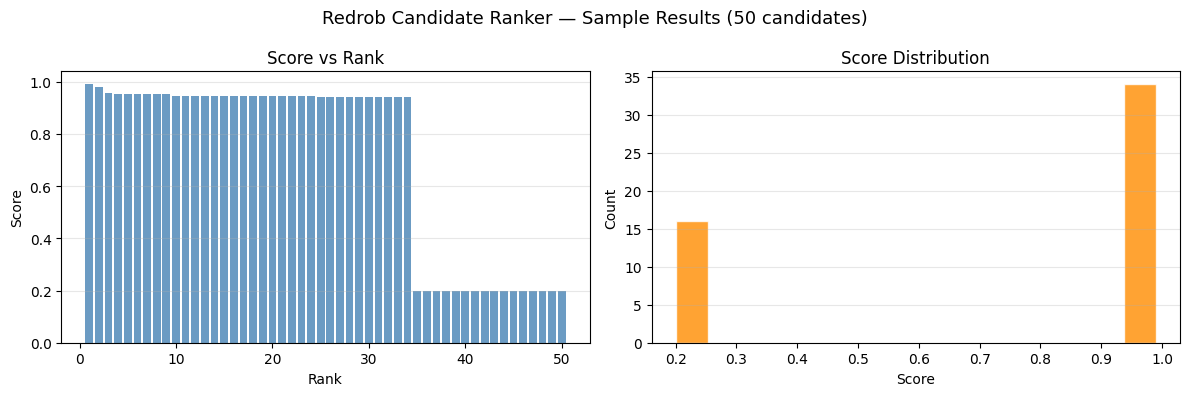

Top score:  0.9900
Min score:  0.2000
Mean score: 0.7087


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df['rank'], df['score'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Score')
axes[0].set_title('Score vs Rank')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df['score'], bins=15, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Redrob Candidate Ranker — Sample Results (50 candidates)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Top score:  {df['score'].max():.4f}")
print(f"Min score:  {df['score'].min():.4f}")
print(f"Mean score: {df['score'].mean():.4f}")

## Step 6: Inspect Top 5 Candidates

In [6]:
import json

with open('sample_candidates.json') as f:
    all_cands = {c['candidate_id']: c for c in json.load(f)}

top5 = df.head(5)
for _, row in top5.iterrows():
    c = all_cands.get(row['candidate_id'], {})
    p = c.get('profile', {})
    sig = c.get('redrob_signals', {})
    skills = [s['name'] for s in c.get('skills', [])[:6]]
    print(f"Rank {int(row['rank'])} | {row['candidate_id']} | Score {row['score']}")
    print(f"  Title    : {p.get('current_title', '?')} | {p.get('years_of_experience', '?')}y exp")
    print(f"  Location : {p.get('location', '?')}, {p.get('country', '?')}")
    print(f"  Skills   : {', '.join(skills)}")
    print(f"  GitHub   : {sig.get('github_activity_score', -1)} | Response rate: {sig.get('recruiter_response_rate', 0):.0%} | Notice: {sig.get('notice_period_days', '?')}d")
    print(f"  Reasoning: {row['reasoning'][:110]}")
    print()

Rank 1 | CAND_0000031 | Score 0.99
  Title    : Recommendation Systems Engineer | 6.0y exp
  Location : Hyderabad, Telangana, India
  Skills   : Go, MLflow, FAISS, Pinecone, Angular, Image Classification
  GitHub   : 32.6 | Response rate: 91% | Notice: 60d
  Reasoning: Recommendation Systems Engineer with 6.0y exp; 7 core AI skills (go, mlflow, faiss, pinecone); loc: Hyderabad,

Rank 2 | CAND_0000001 | Score 0.9794
  Title    : Backend Engineer | 6.9y exp
  Location : Toronto, Canada
  Skills   : Tailwind, NLP, Image Classification, Fine-tuning LLMs, Weights & Biases, Speech Recognition
  GitHub   : 9.2 | Response rate: 34% | Notice: 60d
  Reasoning: Backend Engineer with 6.9y exp; 3 core AI skills (nlp, fine-tuning llms, aws, flask); loc: Toronto, Canada; re

Rank 3 | CAND_0000027 | Score 0.9556
  Title    : DevOps Engineer | 3.9y exp
  Location : Kolkata, West Bengal, India
  Skills   : Docker, YOLO, PEFT, Webpack, Data Science, AWS
  GitHub   : 38.6 | Response rate: 58% | Notice: 90

---
**Repo:** https://github.com/Kritansh-Tank/redrob-ranker  
**Full run command (100K candidates):**
```bash
python rank.py --candidates ./candidates.jsonl --out ./submission.csv
```
Runtime: ~40 seconds | CPU only | No external APIs